<a href="https://colab.research.google.com/github/jessellbanda/CV_Tirana_2026/blob/main/CV_Test_Jessell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

The size of the image is: (303, 384) pixels


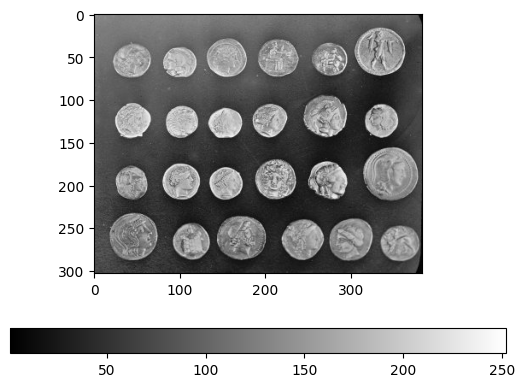

In [9]:
import skimage as sk
import matplotlib.pyplot as plt

img = sk.data.coins()
fig, ax = plt.subplots()

im = ax.imshow(img, cmap='gray')

print('The size of the image is:',img.shape, 'pixels')
fig.colorbar(im, ax=ax ,orientation='horizontal')
plt.show()


## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

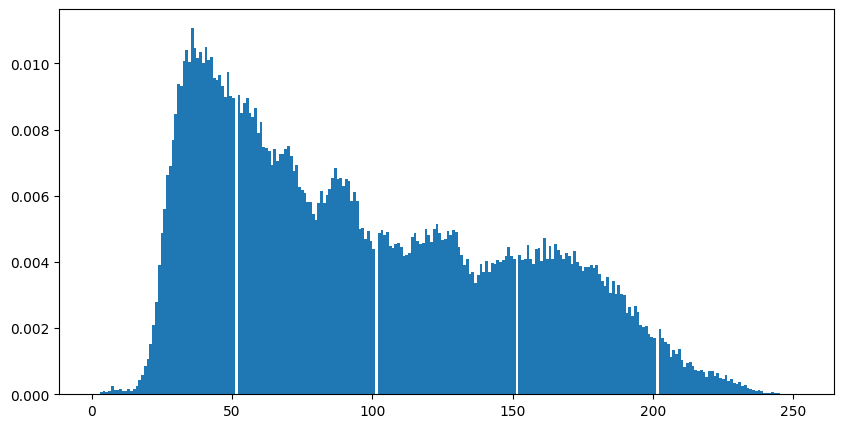

In [12]:
v = img.ravel()
plt.figure(figsize=(10, 5))
plt.hist(v, bins=256, density=True)
plt.show()

## 3. Applied noise to the image and use the correct function to erase the noise.

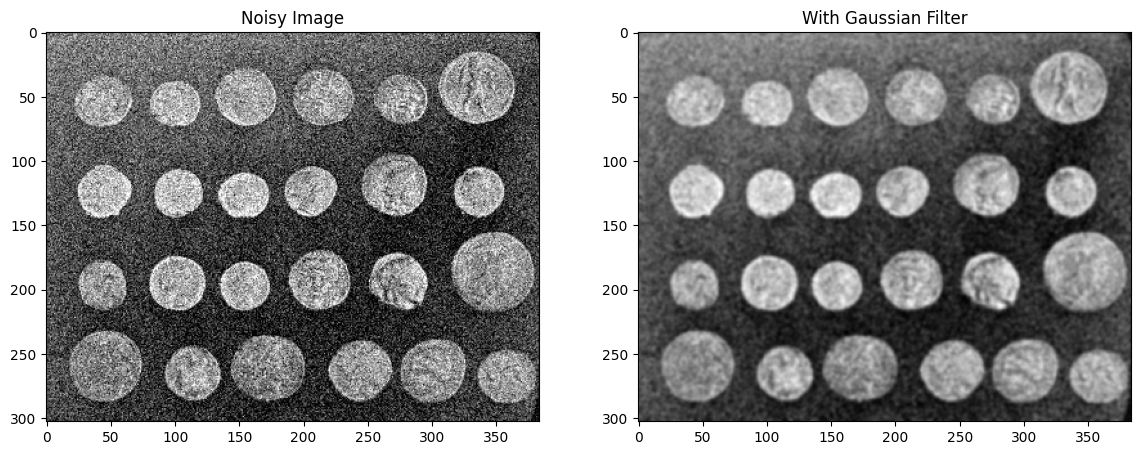

In [21]:
from skimage.filters import gaussian
from skimage import img_as_ubyte
from skimage.util import random_noise

sigma = 0.15
noisy_gaussian = img_as_ubyte(random_noise(img, var=sigma**2))
denoised_img = gaussian(noisy_gaussian, sigma=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(noisy_gaussian, cmap='gray')
axes[0].set_title("Noisy Image")

axes[1].imshow(denoised_img, cmap='gray')
axes[1].set_title("With Gaussian Filter")

plt.show()

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

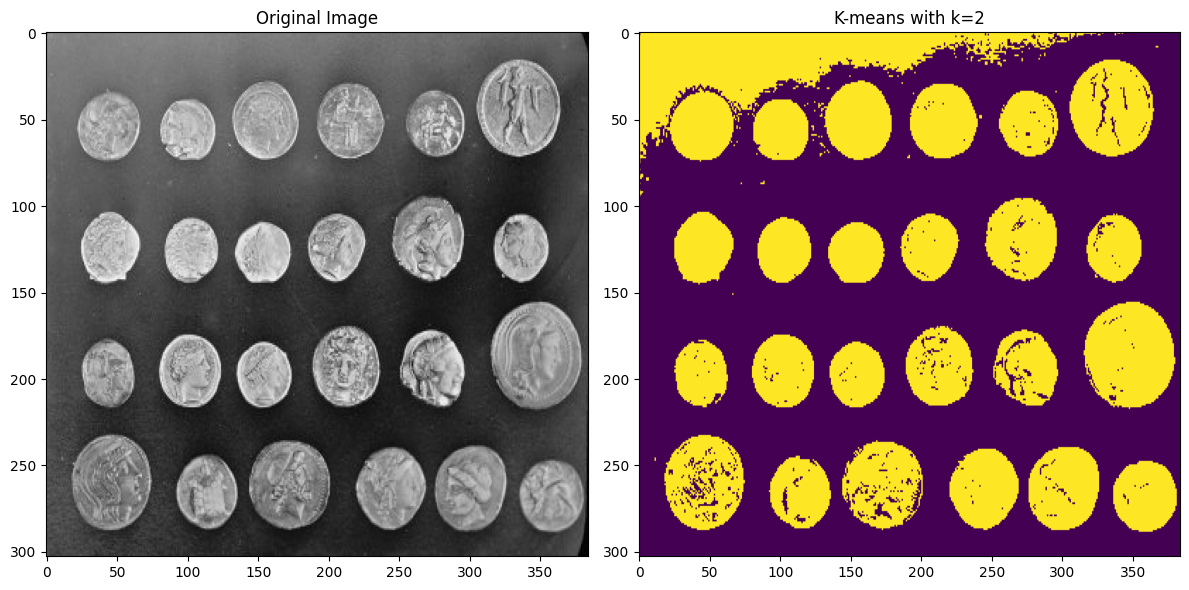

In [24]:
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans


h, w = img.shape
X_pixels = img.reshape((h * w, 1))

n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0, n_init='auto')
v_kmeans = kmeans.fit_predict(X_pixels)
I_kmeans = v_kmeans.reshape((h, w))

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img, aspect='auto', cmap='gray')
ax1.set_title('Original Image', fontsize=12)

ax2 = fig.add_subplot(gs[0, 1])
im_cluster = ax2.imshow(I_kmeans, cmap='viridis', aspect='auto')
ax2.set_title(f'K-means with k=2', fontsize=12)


plt.tight_layout()
plt.show()

## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

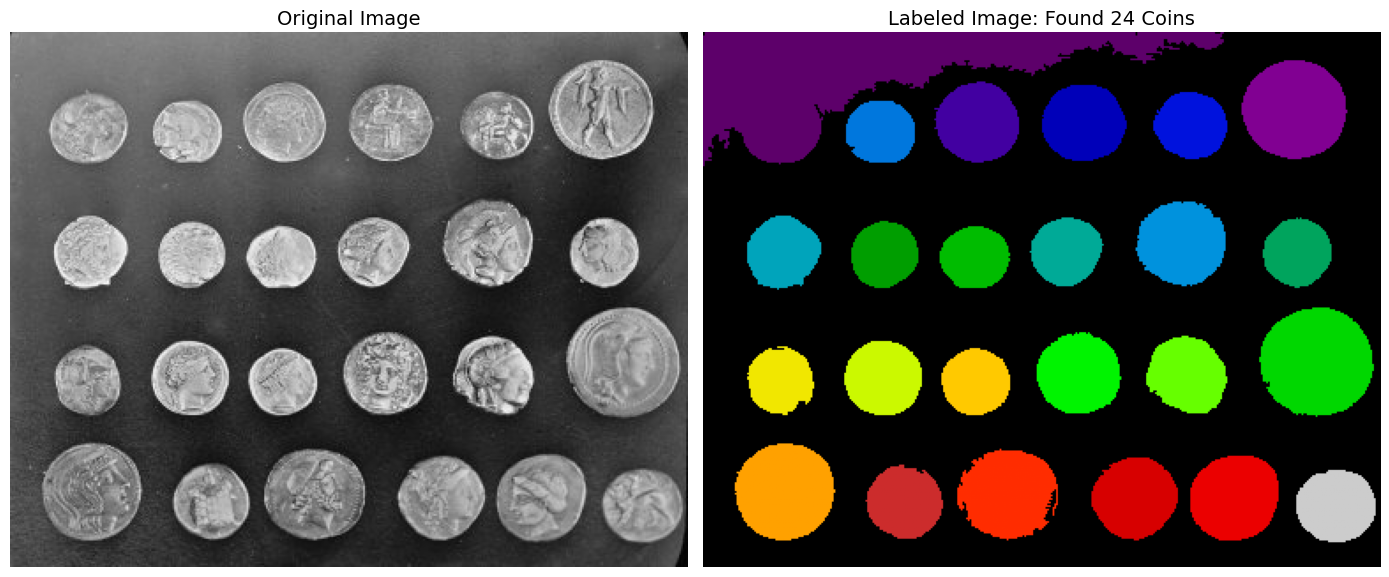

In [35]:
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import closing, remove_small_objects
from scipy import ndimage as ndi

thresh = threshold_otsu(img)
binary = img > thresh

binary_filled = ndi.binary_fill_holes(binary)
binary_cleaned = remove_small_objects(binary_filled, min_size=150)

labeled_image = label(binary_cleaned, background=0)
num_coins = labeled_image.max()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image', fontsize=14)
ax[0].axis('off')

im_seg = ax[1].imshow(labeled_image, cmap='nipy_spectral')
ax[1].set_title(f'Labeled Image: Found {num_coins} Coins', fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  

Average Area: 1627.22 pixels
Average Major Axis Length: 46.52 pixels
Average Orientation: 0.22 radians


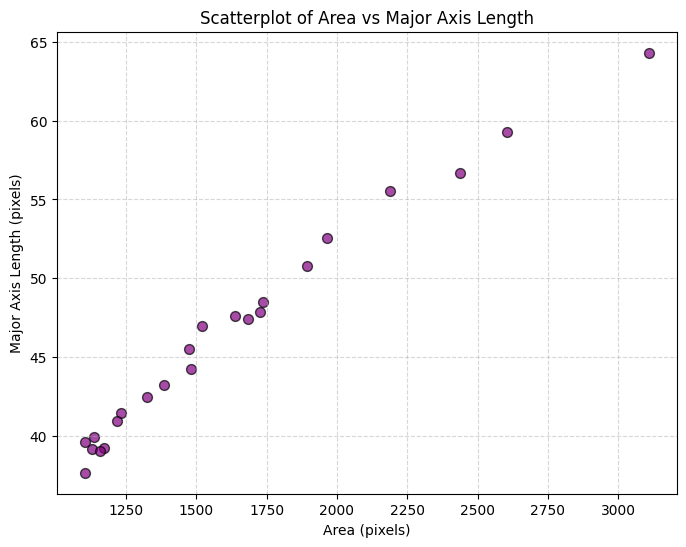

In [38]:
properties = regionprops(labeled_image)

areas = [prop.area for prop in properties if prop.area < 4000]
major_axes = [prop.major_axis_length for prop in properties if prop.area < 4000]
orientations = [prop.orientation for prop in properties if prop.area < 4000]

print(f"Average Area: {np.mean(areas):.2f} pixels")
print(f"Average Major Axis Length: {np.mean(major_axes):.2f} pixels")
print(f"Average Orientation: {np.mean(orientations):.2f} radians")

plt.figure(figsize=(8, 6))
plt.scatter(areas, major_axes, color='purple', alpha=0.7, edgecolors='k', s=50)
plt.title('Scatterplot of Area vs Major Axis Length')
plt.xlabel('Area (pixels)')
plt.ylabel('Major Axis Length (pixels)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [39]:
properties = regionprops(labeled_image)

large_coins = [prop for prop in properties if 1750 < prop.area < 4000]
num_large_coins = len(large_coins)

print(f"Number of coins with an area greater than 1750 pixels: {num_large_coins}")

Number of coins with an area greater than 1750 pixels: 6


##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

## 10. Extract the main texture features of this image

## Personal discussion

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)